In [ ]:
!pip install -q ultralytics
import torch
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
CUDA: True | Tesla T4


In [ ]:
!curl -L "https://app.roboflow.com/ds/v9CHrwvjTn?key=2YG38OYxg9" -o roboflow.zip
!mkdir -p /content/data && unzip -q -o roboflow.zip -d /content/data
print("Da tai va giai nen.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   904  100   904    0     0   2993      0 --:--:-- --:--:-- --:--:--  3003
100 44.1M  100 44.1M    0     0  25.9M      0  0:00:01  0:00:01 --:--:-- 48.0M
Da tai va giai nen.


In [ ]:
import os, glob, yaml
yaml_path = glob.glob('/content/data/**/data.yaml', recursive=True)[0]
BASE = os.path.dirname(yaml_path)
with open(yaml_path) as f: d = yaml.safe_load(f)

d['path']  = BASE
d['train'] = 'train/images'
d['val']   = 'valid/images' if os.path.isdir(f'{BASE}/valid/images') else 'val/images'
d['test']  = 'test/images'  if os.path.isdir(f'{BASE}/test/images')  else d['val']
with open(yaml_path, 'w') as f: yaml.safe_dump(d, f, sort_keys=False)

print("data.yaml:", yaml_path)
print("So lop:", d['nc'], "| Ten lop:", d['names'])
for s in ['train', 'valid', 'test']:
    p = f'{BASE}/{s}/images'
    if os.path.isdir(p): print(f"  {s}: {len(os.listdir(p))} anh")

data.yaml: /content/data/data.yaml
So lop: 6 | Ten lop: ['close_eyeL', 'close_eyeR', 'no_yawn', 'open_eyeL', 'open_eyeR', 'yawn']
  train: 1014 anh
  valid: 290 anh
  test: 144 anh


In [ ]:
from ultralytics import YOLO

# ===== BEST PARAMS (YOLO) =====
BEST = dict(model="yolo11n.pt", epochs=60, imgsz=640, batch=16, patience=20)
print("BEST PARAMS:", BEST)

model = YOLO(BEST["model"])
results = model.train(
    data=yaml_path,
    epochs=BEST["epochs"],
    imgsz=BEST["imgsz"],
    batch=BEST["batch"],
    patience=BEST["patience"],
    device=0,                 # GPU
    project="runs", name="driver_yawn", plots=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
BEST PARAMS: {'model': 'yolo11n.pt', 'epochs': 60, 'imgsz': 640, 'batch': 16, 'patience': 20}
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=tor

In [ ]:
metrics = model.val()
print("mAP50    :", round(metrics.box.map50, 4))
print("mAP50-95 :", round(metrics.box.map,   4))
print("precision:", round(metrics.box.mp,    4))
print("recall   :", round(metrics.box.mr,    4))

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1334.6±592.9 MB/s, size: 30.2 KB)
val: Scanning /content/data/valid/labels.cache... 290 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 290/290 110.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.4it/s 5.6s
                   all        290        814       0.89      0.921      0.955      0.723
            close_eyeL        133        133      0.807      0.917      0.923      0.615
            close_eyeR        138        138      0.825      0.942      0.937      0.713
               no_yawn         47         47      0.923          1      0.995      0.814
             open_eyeL        126        126      0.896      0.821      0.938      0.721
             open_eyeR        126        126    

rundir: /content/runs/detect/runs/driver_yawn
/content/runs/detect/runs/driver_yawn/results.png


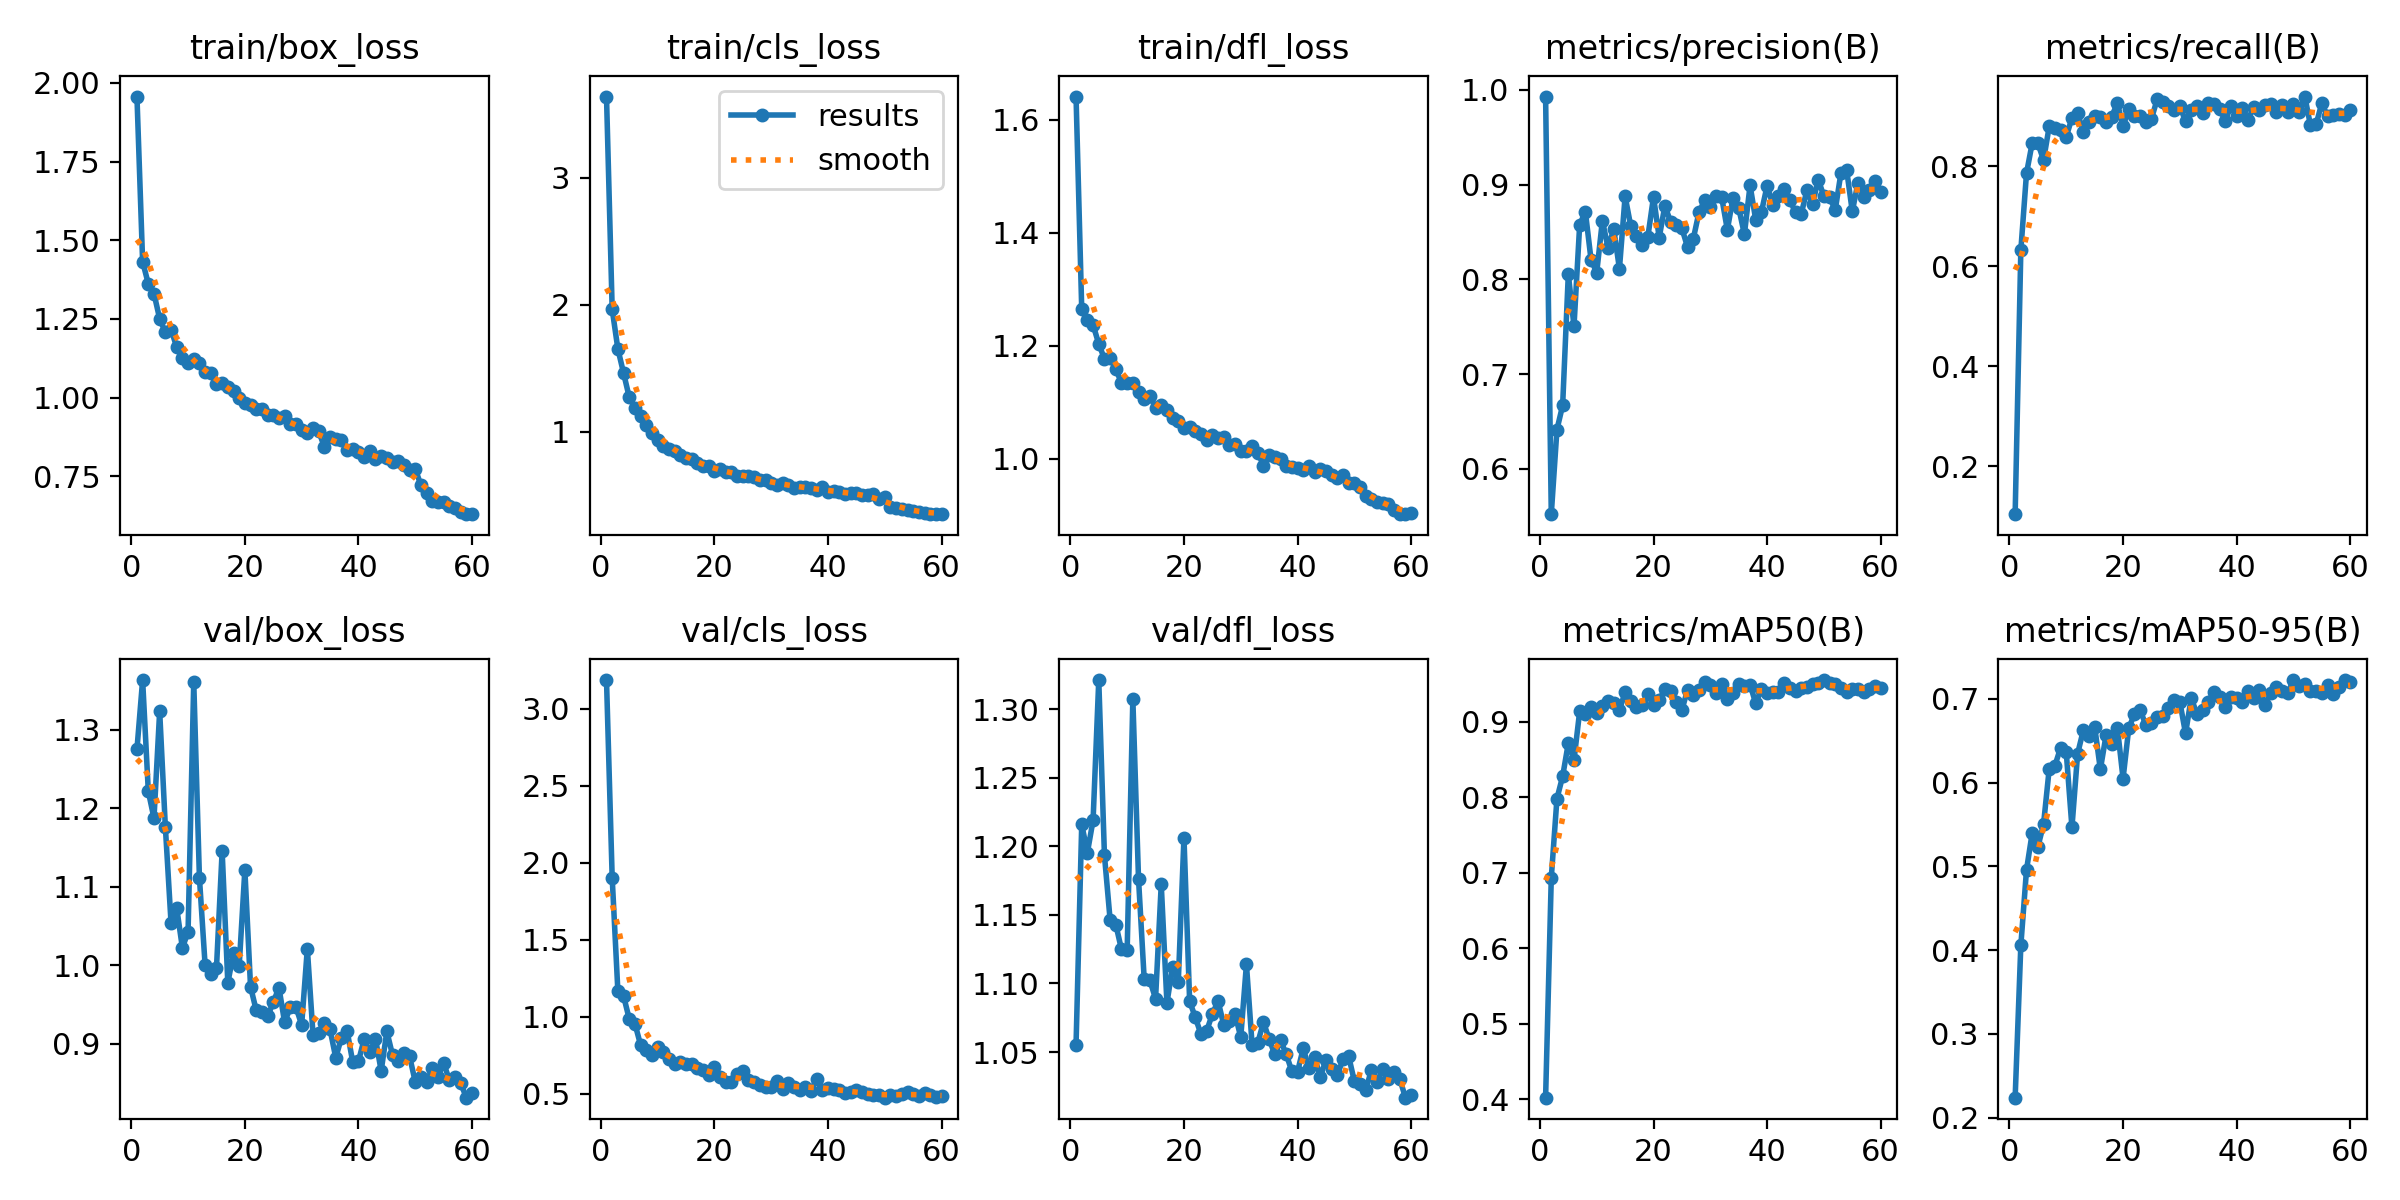

/content/runs/detect/runs/driver_yawn/confusion_matrix.png


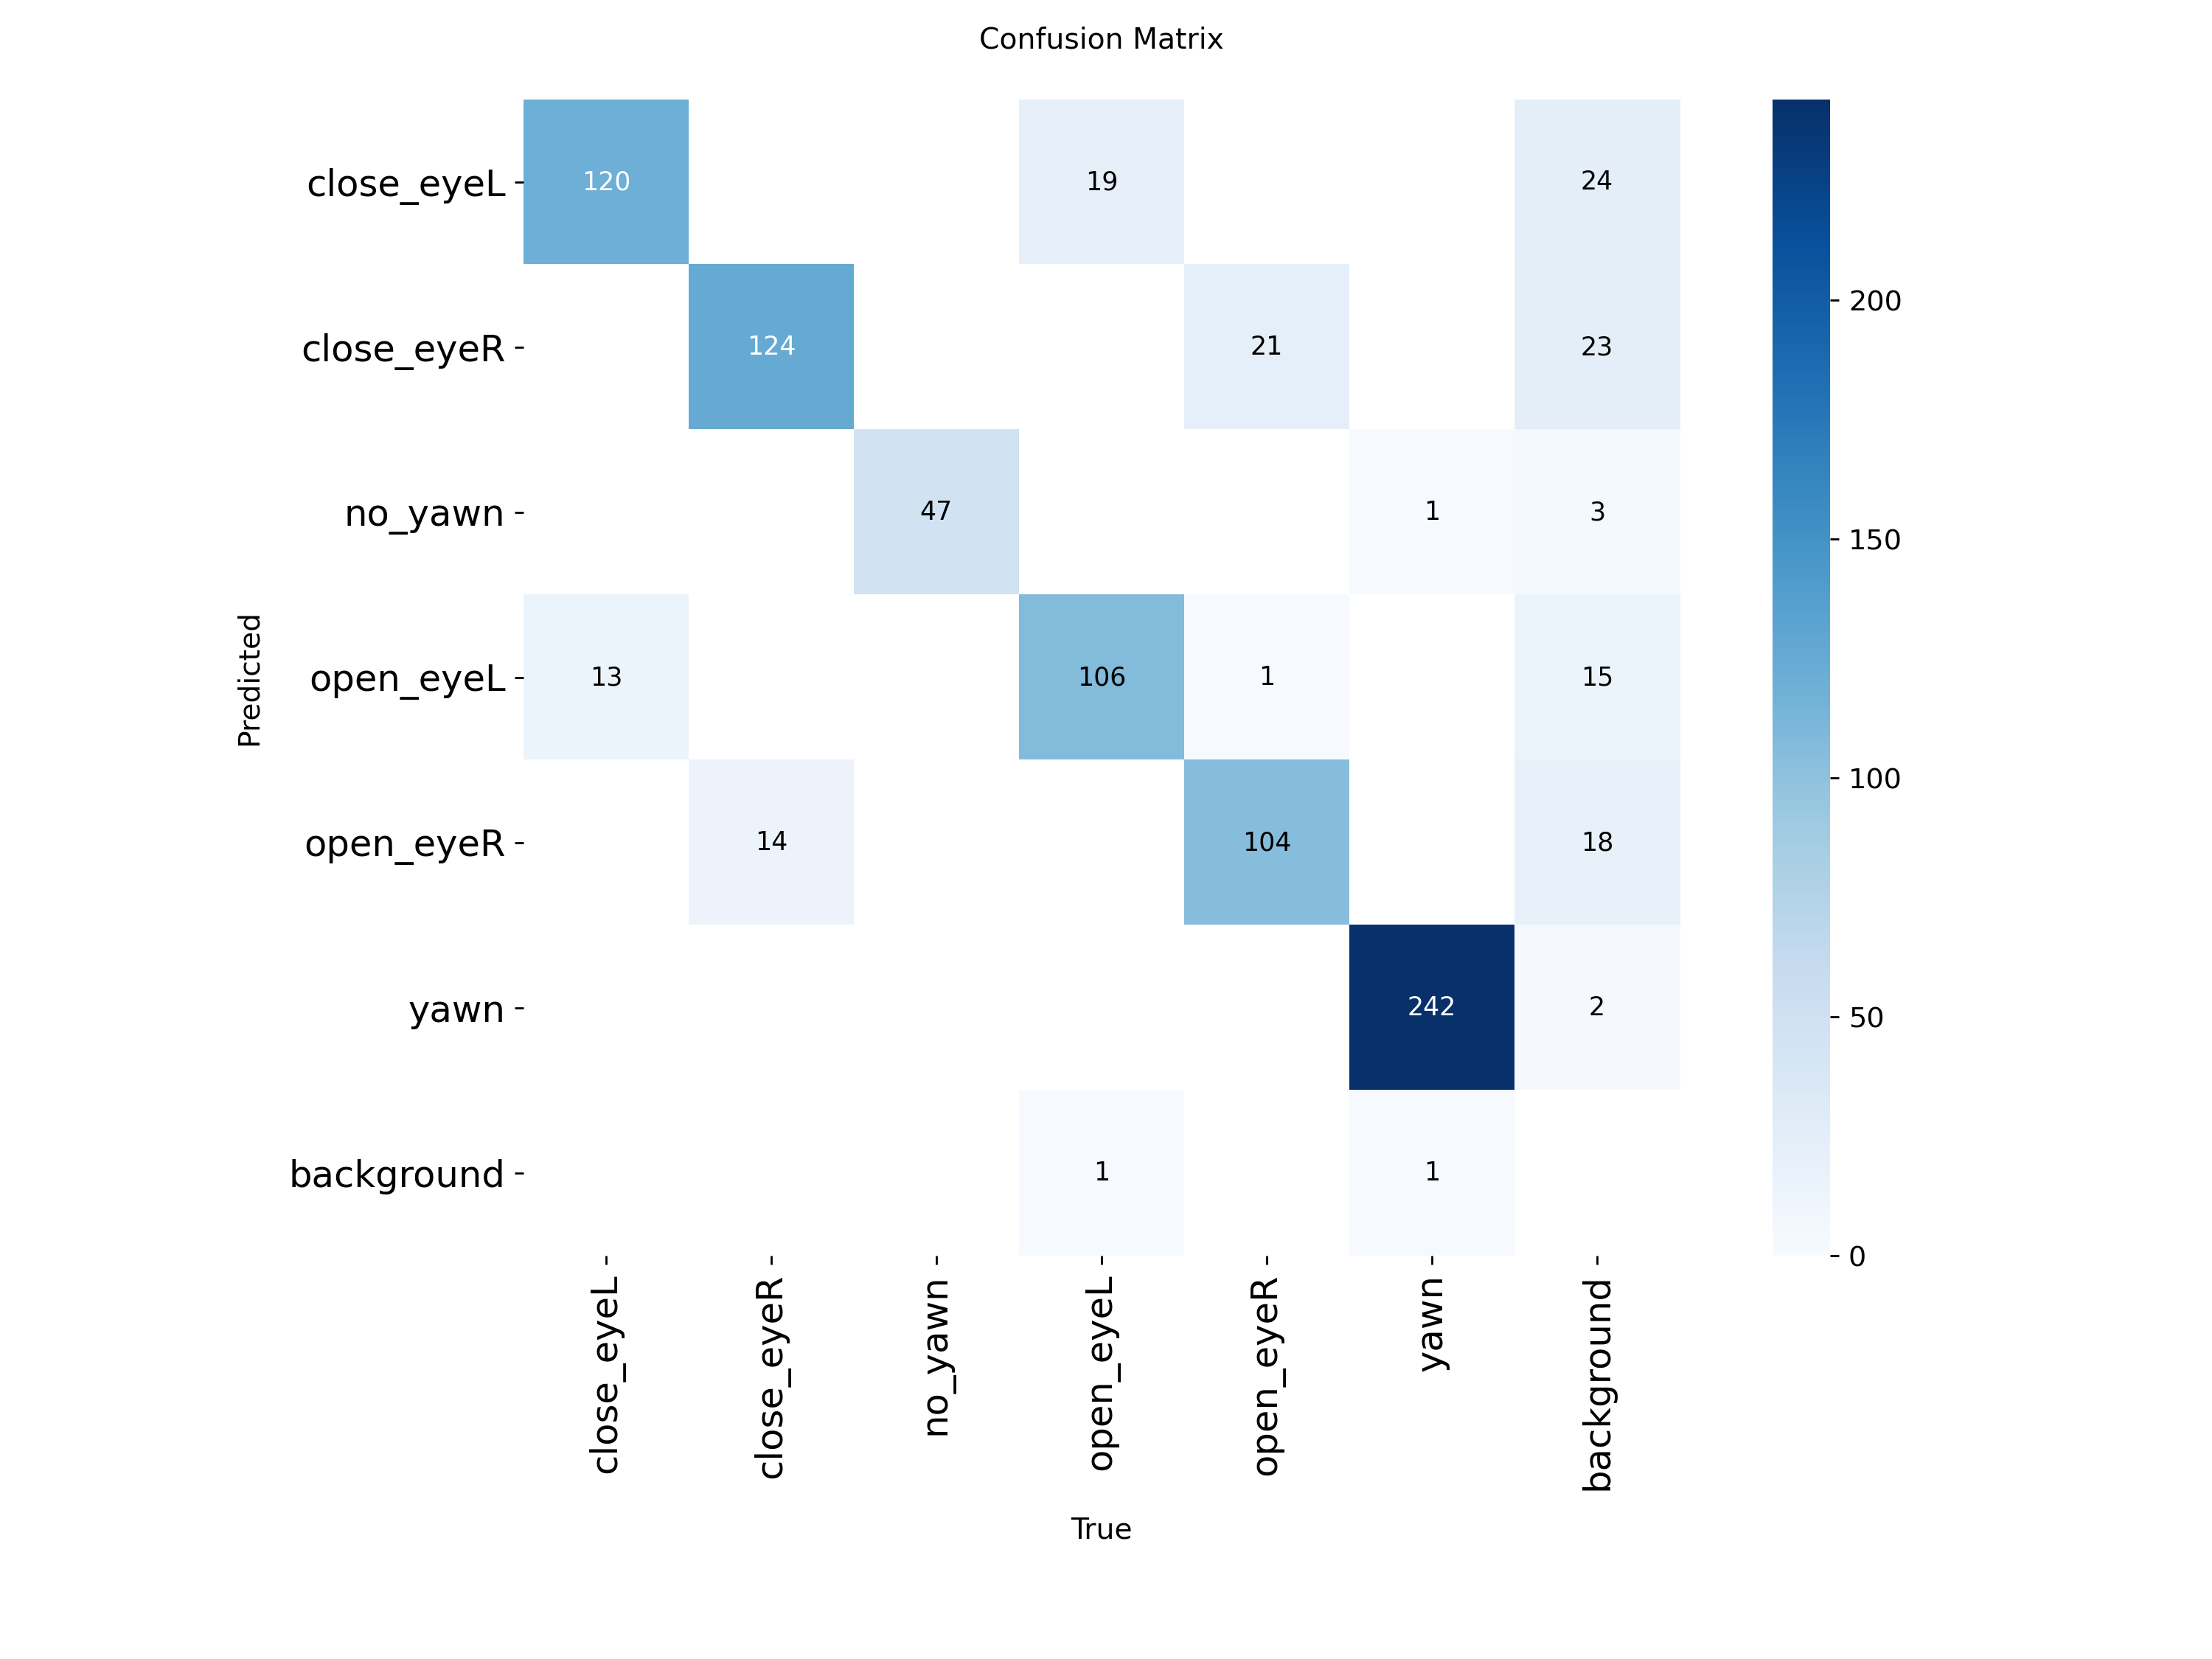

/content/runs/detect/runs/driver_yawn/val_batch0_pred.jpg


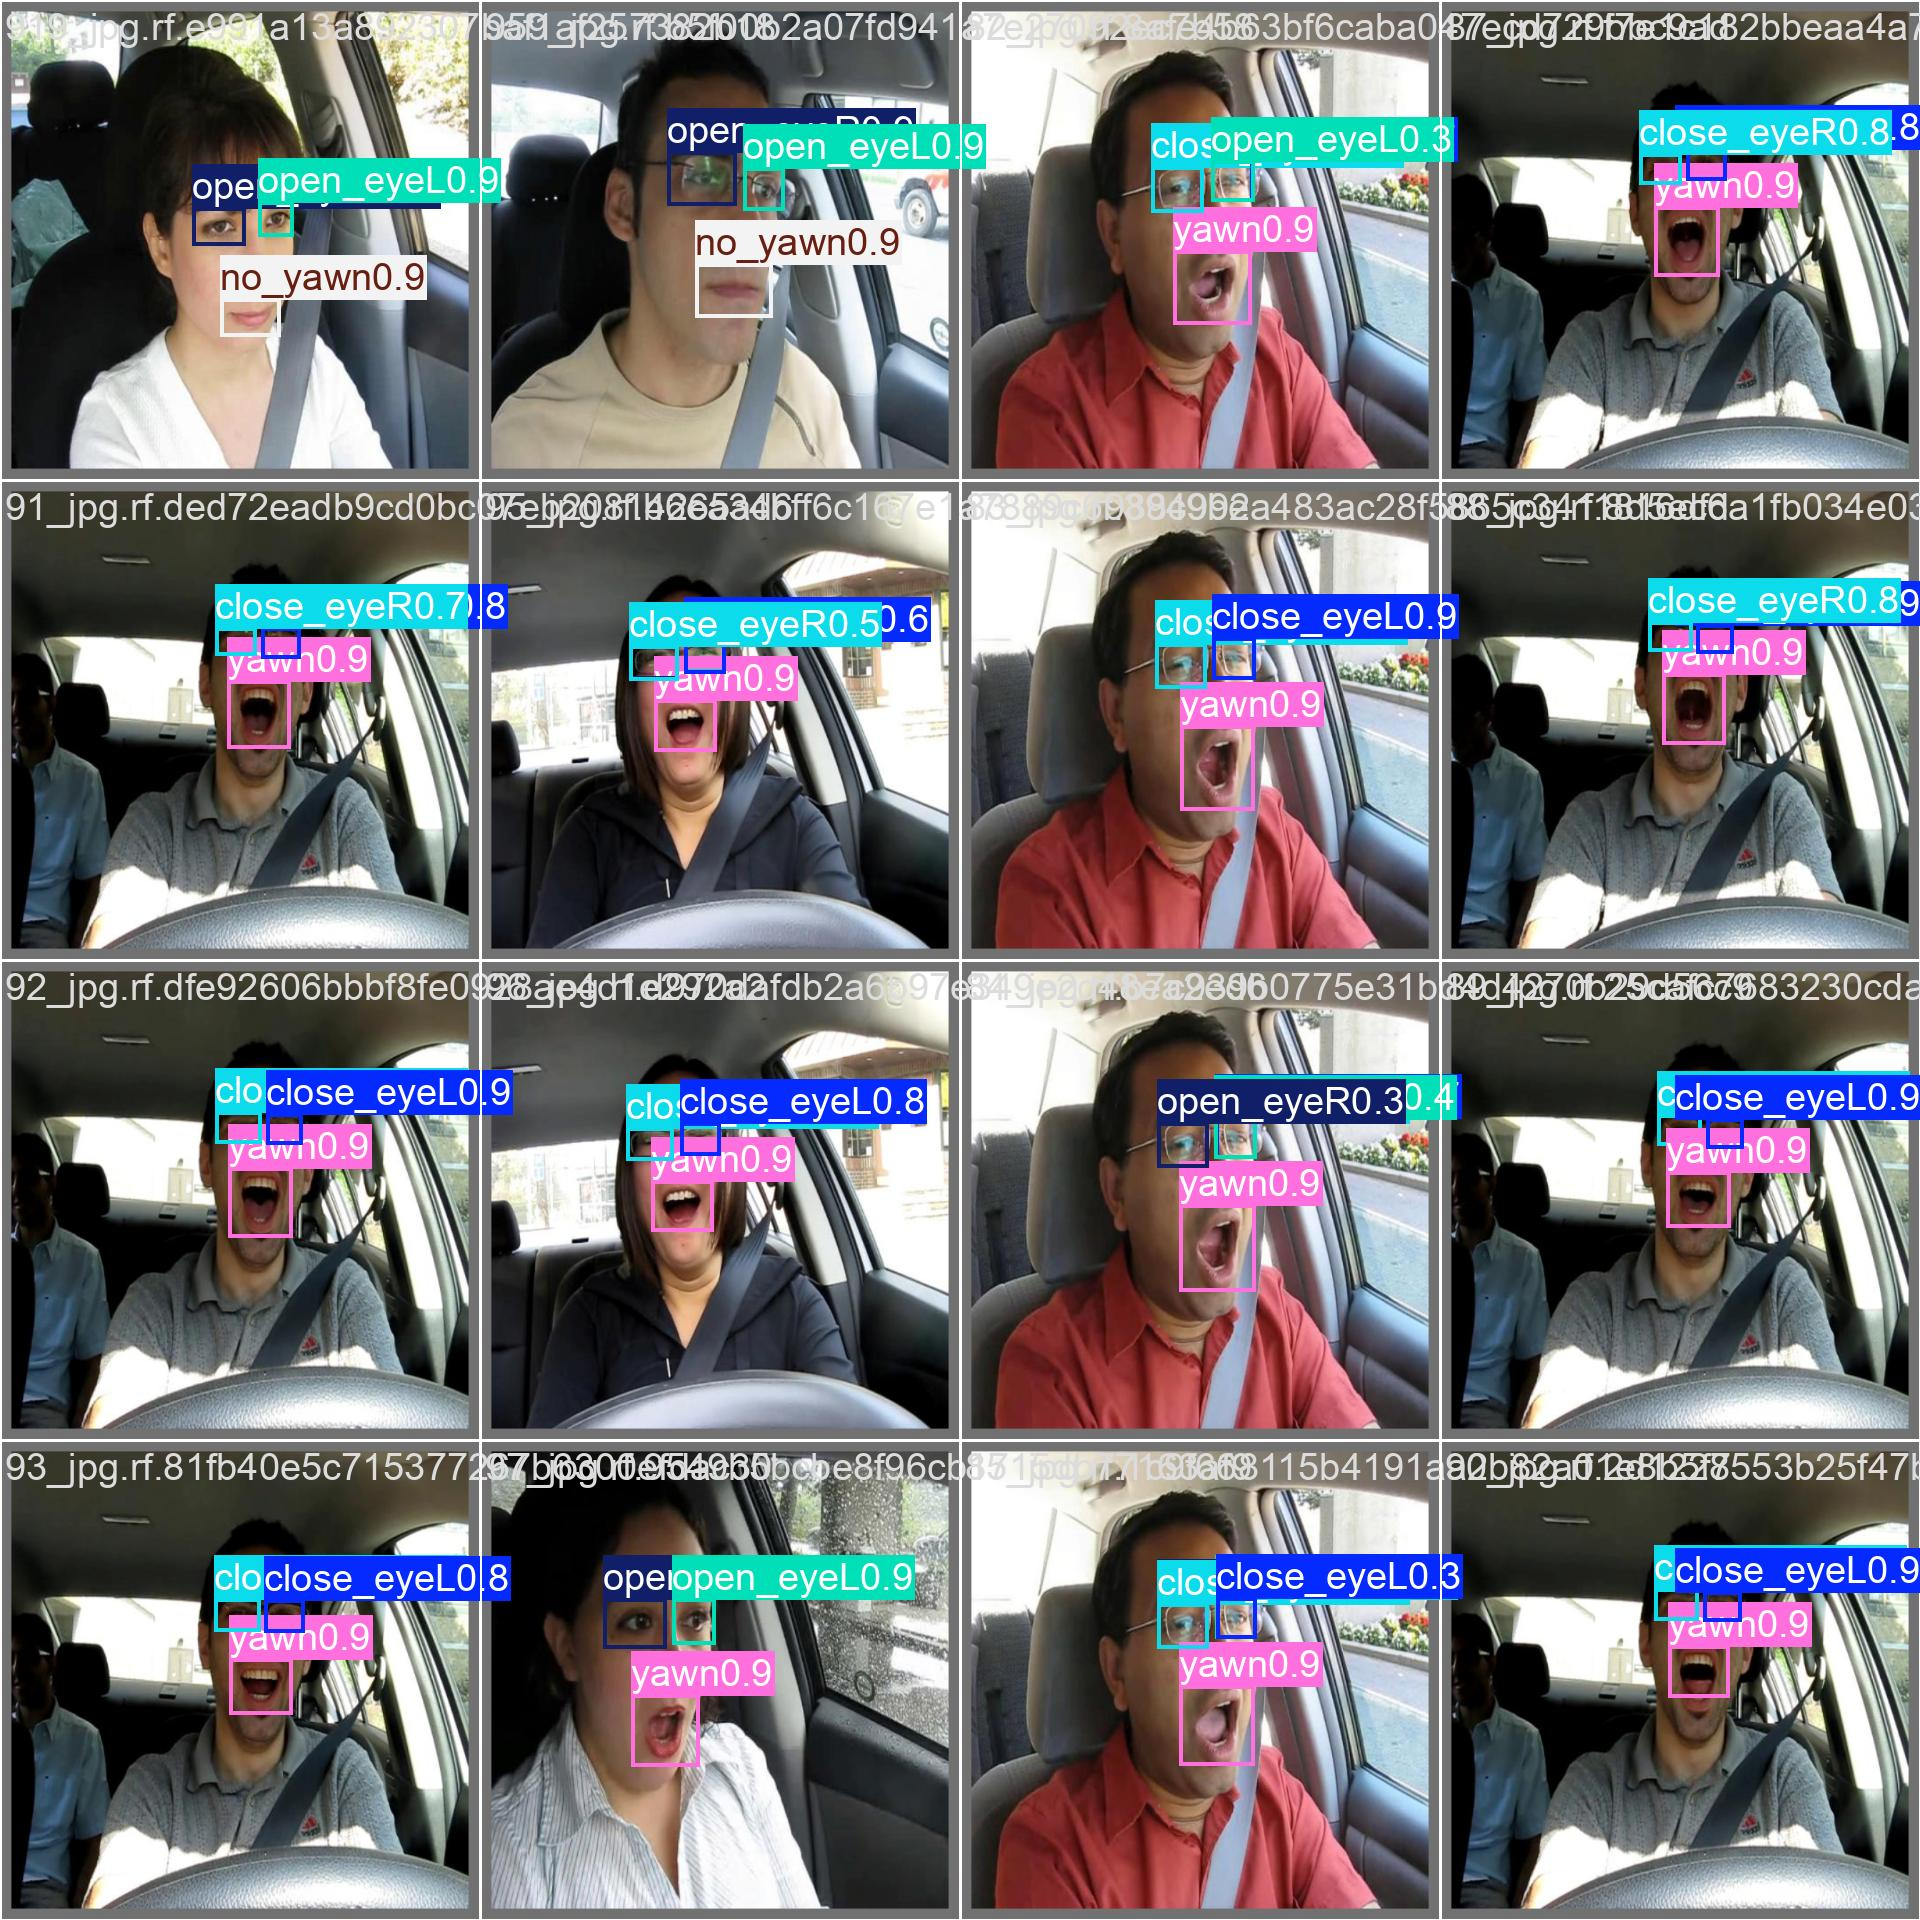

In [ ]:
from IPython.display import Image, display
import glob, os

# Lay dung thu muc run tu trainer (chinh xac, khong phu thuoc ten)
rundir = str(model.trainer.save_dir)
print("rundir:", rundir)

for img in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = os.path.join(rundir, img)
    if os.path.exists(p):
        print(p); display(Image(p))

In [ ]:
import os
best = os.path.join(rundir, 'weights', 'best.pt')
print("best.pt:", best, "| ton tai:", os.path.exists(best))

from ultralytics import YOLO
m = YOLO(best)
tflite = m.export(format='tflite', imgsz=BEST["imgsz"])
print("TFLite:", tflite)

from google.colab import files
files.download(best)
files.download(str(tflite))

best.pt: /content/runs/detect/runs/driver_yawn/weights/best.pt | ton tai: True
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/runs/driver_yawn/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 288ms
Prepared 4 packages in 1.74s
Installed 4 packages in 231ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for up

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>